# R(2) NLTL scan fit with cached-field differential evolution

This notebook is a variant of `r2_nltl_scan_fit.ipynb`.

Main changes:

- Uses `scipy.optimize.differential_evolution` for the expensive physical coordinates.
- Treats electric field and power as expensive discrete/cached coordinates:
  the optimizer searches over integer `field_index` and `power_index` values.
- Caches raw OBE detuning traces by `(field_index, power_index)` so candidates
  with different Doppler widths reuse the same solved trace.
- Profiles `ir_zero_MHz` and the total amplitude scale inside the objective; they
  are fit parameters, but not differential-evolution coordinates.
- Uses the weighted initial population:
  `2/3` in `F=2,mF=0` and `1/9` each in `F=3,mF=-1,0,+1`.

The differential-evolution variables are:

- `power_index`, decoded through a log-spaced `power_mW` grid
- `field_index`, decoded through `E_GRID_V_CM`, spanning `160..190 V/cm`
- `sigma_v`, spanning `0..2 m/s`

In [1]:
from __future__ import annotations

import inspect
import time
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.constants as cst
import scipy.optimize as opt
from IPython.display import clear_output, display
from scipy.optimize._differentialevolution import DifferentialEvolutionSolver
import scipy.signal as signal
import sympy as smp

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
from centrex_tlf.lindblad.parameters import LindbladParameters
from centrex_tlf.lindblad.plan_static import prepare_lindblad_problem
from centrex_tlf.utils import population
from centrex_tlf.utils.rabi import (
    power_to_intensity_rectangular_beam,
    power_to_rabi_rectangular_beam,
)

plt.rcParams.update({"font.size": 14})

GAMMA = getattr(hamiltonian, "\u0393")
NOTEBOOK_DIR = Path.cwd()
CSV_PATH = NOTEBOOK_DIR / "digitized_det1_nltl_scan.csv"
if not CSV_PATH.exists():
    CSV_PATH = Path("examples/lindblad/digitized_det1_nltl_scan.csv")

## Configuration

In [2]:
transition = transitions.R2_F1_7o2_F3

B_FIELD = np.array([0.0, 0.0, 1e-5])  # G
BEAM_WX = 0.02  # m
BEAM_WY = 0.02  # m
VELOCITY = 184.0  # m/s
INTERACTION_LENGTH = 0.02  # m
T_END = INTERACTION_LENGTH / VELOCITY

INITIAL_F1 = 5 / 2
INITIAL_F = 2
INITIAL_MF = 0

# F=2/F=3 initial population from the opposite-parity retention notebook.
INITIAL_POPULATION_SELECTORS = [
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F, mF=INITIAL_MF),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=-1),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=0),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=+1),
]
INITIAL_POPULATION_WEIGHTS = np.array([2 / 3, 1 / 9, 1 / 9, 1 / 9], dtype=float)

OPTICAL_FREQUENCY_HZ = 1.1e15
OPTICAL_WAVELENGTH_M = cst.c / OPTICAL_FREQUENCY_HZ

# Expensive field coordinate. Differential evolution treats this as an integer
# coordinate through the integrality mask.
E_MIN_V_CM = 160.0
E_MAX_V_CM = 190.0
E_STEP_V_CM = 5
E_GRID_V_CM = np.arange(E_MIN_V_CM, E_MAX_V_CM + 0.5 * E_STEP_V_CM, E_STEP_V_CM)
START_E_FIELD_V_CM = 171.6
START_FIELD_INDEX = int(np.argmin(np.abs(E_GRID_V_CM - START_E_FIELD_V_CM)))

# Expensive power coordinate. Differential evolution treats this as an integer
# coordinate through the integrality mask, decoded to a log-spaced power grid.
POWER_BOUNDS_MW = (0.1, 80.0)
START_POWER_MW = 40.0
POWER_CACHE_STEP_LOG10 = 0.01
LOG_POWER_GRID = np.arange(
    np.log10(POWER_BOUNDS_MW[0]),
    np.log10(POWER_BOUNDS_MW[1]) + 0.5 * POWER_CACHE_STEP_LOG10,
    POWER_CACHE_STEP_LOG10,
)
POWER_GRID_MW = 10**LOG_POWER_GRID
START_POWER_INDEX = int(np.argmin(np.abs(POWER_GRID_MW - START_POWER_MW)))

SIGMA_V_BOUNDS_M_PER_S = (0.0, 2.0)
START_SIGMA_V_M_PER_S = 1.4

FIT_DETUNING_STEP_MHZ = 2.0
FINAL_DETUNING_STEP_MHZ = 0.25

FIT_REL_TOL = 3e-7
FIT_ABS_TOL = 3e-9
FINAL_REL_TOL = 1e-7
FINAL_ABS_TOL = 1e-9

DETUNING_PADDING_MHZ = 15.0
CONV_EDGE_PADDING_SIGMA = 4.0
SCAN_THREADS = None  # None lets the Rust backend choose.

IR_ZERO_GRID_HALF_WIDTH_MHZ = 5.0
IR_ZERO_PROFILE_STEP_MHZ = 0.05

# Differential evolution settings. These are intentionally modest because each
# new cached (field, power) point performs an OBE scan.
DE_SEED = 12345
DE_POPSIZE = 8
DE_MAXITER = 20
DE_TOL = 0.02
DE_POLISH = False
DE_WORKERS = 1  # avoid nested parallelism with the Rust OBE scans

# The scale is always profiled analytically. Keep False unless you have a real
# reason to float a vertical offset.
FIT_BASELINE_TOO = False
REQUIRE_NONNEGATIVE_SCALE = True

config = {
    "transition": transition.name,
    "beam_cm_by_cm": (BEAM_WX * 100, BEAM_WY * 100),
    "velocity_m_per_s": VELOCITY,
    "interaction_time_us": T_END * 1e6,
    "field_grid_V_per_cm": (float(E_GRID_V_CM[0]), float(E_GRID_V_CM[-1]), float(E_STEP_V_CM)),
    "start_field_V_per_cm": float(E_GRID_V_CM[START_FIELD_INDEX]),
    "power_bounds_mW": POWER_BOUNDS_MW,
    "power_cache_step_log10": POWER_CACHE_STEP_LOG10,
    "power_grid_points": int(LOG_POWER_GRID.size),
    "start_power_mW": float(POWER_GRID_MW[START_POWER_INDEX]),
    "sigma_v_bounds_m_per_s": SIGMA_V_BOUNDS_M_PER_S,
    "fit_detuning_step_MHz": FIT_DETUNING_STEP_MHZ,
    "final_detuning_step_MHz": FINAL_DETUNING_STEP_MHZ,
    "ir_zero_profile_step_MHz": IR_ZERO_PROFILE_STEP_MHZ,
    "nominal_intensity_mW_per_cm2": power_to_intensity_rectangular_beam(
        START_POWER_MW * 1e-3, BEAM_WX, BEAM_WY
    )
    * 0.1,
}
config

{'transition': "R(2) F1'=7/2 F'=3",
 'beam_cm_by_cm': (2.0, 2.0),
 'velocity_m_per_s': 184.0,
 'interaction_time_us': 108.69565217391305,
 'field_grid_V_per_cm': (160.0, 190.0, 5.0),
 'start_field_V_per_cm': 170.0,
 'power_bounds_mW': (0.1, 80.0),
 'power_cache_step_log10': 0.01,
 'power_grid_points': 291,
 'start_power_mW': 39.81071705534994,
 'sigma_v_bounds_m_per_s': (0.0, 2.0),
 'fit_detuning_step_MHz': 2.0,
 'final_detuning_step_MHz': 0.25,
 'ir_zero_profile_step_MHz': 0.05,
 'nominal_intensity_mW_per_cm2': 10.0}

## Load digitized scan and identify the data peaks

The CSV x axis is IR MHz. The optical detuning convention is

`delta_uv_MHz = -4 * (frequency_ir_MHz - ir_zero_MHz)`.

In [3]:
data = np.genfromtxt(CSV_PATH, delimiter=",", names=True)
x_ir_MHz = np.asarray(data["frequency_MHz"], dtype=float)
y_data = np.asarray(data["y"], dtype=float)
sy_data = np.asarray(data["sy"], dtype=float)
sy_data = np.where(sy_data > 0, sy_data, np.nanmedian(sy_data[sy_data > 0]))


def quadratic_peak_center(
    x: np.ndarray,
    y: np.ndarray,
    idx: int,
    half_width: int = 2,
) -> tuple[float, float]:
    lo = max(0, idx - half_width)
    hi = min(x.size, idx + half_width + 1)
    if hi - lo < 3:
        return float(x[idx]), float(y[idx])

    coeff = np.polyfit(x[lo:hi], y[lo:hi], deg=2)
    a, b, c = coeff
    if a >= 0:
        return float(x[idx]), float(y[idx])

    x0 = -b / (2 * a)
    if x0 < x[lo] or x0 > x[hi - 1]:
        return float(x[idx]), float(y[idx])

    y0 = np.polyval(coeff, x0)
    return float(x0), float(y0)


def find_two_data_peaks(x: np.ndarray, y: np.ndarray) -> dict[str, float]:
    prominence = max(0.1 * (np.nanmax(y) - np.nanmin(y)), np.nanmedian(sy_data))
    peaks, props = signal.find_peaks(y, distance=3, prominence=prominence)
    if peaks.size < 2:
        local = []
        for i in range(1, y.size - 1):
            if y[i] >= y[i - 1] and y[i] >= y[i + 1]:
                local.append(i)
        peaks = np.asarray(local, dtype=int)

    if peaks.size < 2:
        peaks = np.argsort(y)[-2:]

    strongest = peaks[np.argsort(y[peaks])[-2:]]
    low_idx, high_idx = sorted(strongest, key=lambda idx: x[idx])

    low_x, low_y = quadratic_peak_center(x, y, int(low_idx))
    high_x, high_y = quadratic_peak_center(x, y, int(high_idx))
    return {
        "opposite_ir_MHz": low_x,
        "opposite_y": low_y,
        "normal_ir_MHz": high_x,
        "normal_y": high_y,
        "separation_ir_MHz": high_x - low_x,
        "separation_uv_MHz": 4.0 * (high_x - low_x),
    }


data_peaks = find_two_data_peaks(x_ir_MHz, y_data)
START_IR_ZERO_MHZ = data_peaks["normal_ir_MHz"]
IR_ZERO_BOUNDS_MHZ = (
    START_IR_ZERO_MHZ - IR_ZERO_GRID_HALF_WIDTH_MHZ,
    START_IR_ZERO_MHZ + IR_ZERO_GRID_HALF_WIDTH_MHZ,
)

data_summary = {
    **data_peaks,
    "ir_zero_start_MHz": START_IR_ZERO_MHZ,
    "ir_zero_bounds_MHz": IR_ZERO_BOUNDS_MHZ,
}
data_summary

{'opposite_ir_MHz': 1830.8143742252769,
 'opposite_y': 0.030311752807392622,
 'normal_ir_MHz': 1837.0751641560157,
 'normal_y': 0.051802076981402934,
 'separation_ir_MHz': 6.260789930738838,
 'separation_uv_MHz': 25.04315972295535,
 'ir_zero_start_MHz': 1837.0751641560157,
 'ir_zero_bounds_MHz': (1832.0751641560157, 1842.0751641560157)}

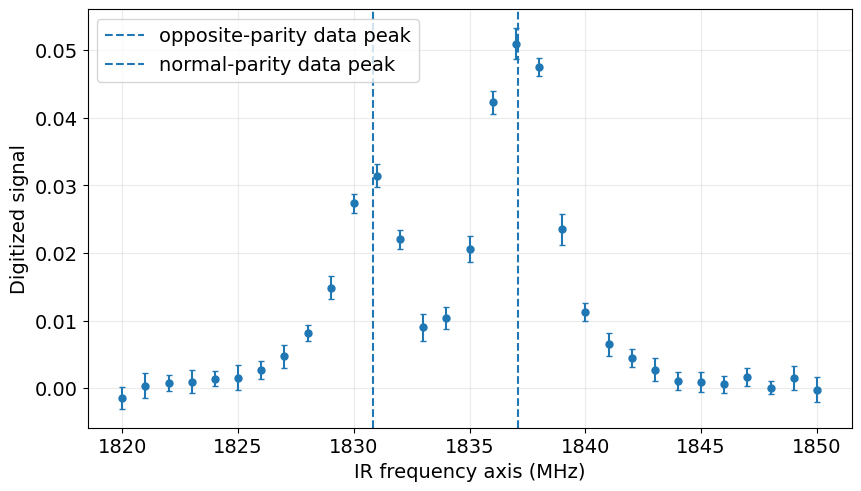

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
ax.errorbar(x_ir_MHz, y_data, yerr=sy_data, fmt="o", ms=5, capsize=2)
ax.axvline(data_peaks["opposite_ir_MHz"], ls="--", label="opposite-parity data peak")
ax.axvline(data_peaks["normal_ir_MHz"], ls="--", label="normal-parity data peak")
ax.set_xlabel("IR frequency axis (MHz)")
ax.set_ylabel("Digitized signal")
ax.grid(alpha=0.25)
ax.legend()

## Transition selectors and cached OBE-system builder

In [5]:
ground_main = 1 * next(
    iter(
        states.generate_coupled_states_X(
            states.QuantumSelector(
                electronic=states.ElectronicState.X,
                J=transition.J_ground,
                F1=INITIAL_F1,
                F=INITIAL_F,
                mF=INITIAL_MF,
                P=transition.P_ground,
            )
        )
    )
)

excited_main = 1 * next(
    iter(
        states.generate_coupled_states_B(
            states.QuantumSelector(
                electronic=states.ElectronicState.B,
                J=transition.J_excited,
                F1=transition.F1_excited,
                F=transition.F_excited,
                mF=1,
                P=transition.P_excited,
            )
        )
    )
)

transition_selectors = couplings.generate_transition_selectors(
    transitions=[transition],
    polarizations=[[couplings.polarization_X]],
    ground_mains=[ground_main],
    excited_mains=[excited_main],
)

RABI_PARAMETER_NAME = "rabi"
DETUNING_PARAMETER_NAME = "detuning"

In [6]:
def selected_initial_population_indices_and_weights(
    system: lindblad.OBESystem,
) -> tuple[np.ndarray, np.ndarray]:
    index_groups = []
    for selector in INITIAL_POPULATION_SELECTORS:
        group = np.asarray(selector.get_indices(system.QN), dtype=int)
        if group.size == 0:
            raise ValueError(f"Initial population selector matched no states: {selector}")
        index_groups.append(group)

    indices = np.concatenate(index_groups)
    weights = np.concatenate(
        [
            np.full(group.size, selector_weight / group.size, dtype=float)
            for group, selector_weight in zip(index_groups, INITIAL_POPULATION_WEIGHTS)
        ]
    )
    return indices, weights


def generate_weighted_population_state_indices_fallback(
    state_indices: np.ndarray,
    levels: int,
    weights: np.ndarray,
) -> np.ndarray:
    state_indices = np.asarray(state_indices, dtype=int)
    weights = np.asarray(weights, dtype=float)
    if state_indices.ndim != 1 or weights.ndim != 1:
        raise ValueError("state_indices and weights must be 1D")
    if state_indices.size == 0:
        raise ValueError("state_indices cannot be empty")
    if state_indices.size != weights.size:
        raise ValueError("state_indices and weights must have the same length")
    if np.any(state_indices < 0) or np.any(state_indices >= levels):
        raise ValueError("state index out of bounds")
    if not np.all(np.isfinite(weights)) or np.any(weights < 0) or np.sum(weights) <= 0:
        raise ValueError("weights must be finite, non-negative, and sum positive")

    rho0 = np.zeros((levels, levels), dtype=np.complex128)
    np.add.at(rho0, (state_indices, state_indices), weights)
    return rho0 / np.trace(rho0)


def initial_density_matrix(system: lindblad.OBESystem) -> np.ndarray:
    indices, weights = selected_initial_population_indices_and_weights(system)

    signature = inspect.signature(population.generate_uniform_population_state_indices)
    if "weights" in signature.parameters:
        return population.generate_uniform_population_state_indices(
            indices,
            len(system.QN),
            weights=weights,
        )

    return generate_weighted_population_state_indices_fallback(
        indices,
        len(system.QN),
        weights,
    )


def excited_indices(system: lindblad.OBESystem) -> list[int]:
    return [
        idx
        for idx, state in enumerate(system.QN)
        if state.largest.electronic_state == states.ElectronicState.B
    ]


def parameter_values(system: lindblad.OBESystem) -> LindbladParameters:
    params = LindbladParameters()
    rabi = params.real(RABI_PARAMETER_NAME, 0.0)
    detuning = params.real(DETUNING_PARAMETER_NAME, 0.0)

    for symbol in system.H_symbolic.free_symbols:
        name = str(symbol)
        if symbol in system.coupling_symbols:
            params.bind(symbol, rabi, finalize=False)
        elif name == str(getattr(transition_selectors[0], "\u03b4")):
            params.bind(symbol, detuning, finalize=False)
        else:
            params.real(name, 0.0)

    for symbol_group in system.polarization_symbols:
        symbols = symbol_group if isinstance(symbol_group, (list, tuple)) else [symbol_group]
        for symbol in symbols:
            params.bind(symbol, 1.0, finalize=False)

    params._finalize()
    return params


def rabi_rate_for_power(system: lindblad.OBESystem, power_mW: float) -> float:
    main_coupling = abs(system.couplings[0].main_coupling)
    return power_to_rabi_rectangular_beam(
        power_mW * 1e-3,
        main_coupling,
        BEAM_WX,
        BEAM_WY,
    )


@dataclass(frozen=True)
class PreparedFitModel:
    field_index: int
    Ez_V_cm: float
    system: lindblad.OBESystem
    params: LindbladParameters
    prepared: object
    rho0: np.ndarray
    photon_integral_weights: list[tuple[int, float]]


FIELD_BUILD_LOG: list[dict[str, float | int]] = []


def field_index_from_coord(field_index_coord: float) -> int:
    idx = int(np.rint(field_index_coord))
    return int(np.clip(idx, 0, E_GRID_V_CM.size - 1))


@lru_cache(maxsize=None)
def build_fit_model(field_index: int, compact: bool = True) -> PreparedFitModel:
    field_index = int(field_index)
    Ez_V_cm = float(E_GRID_V_CM[field_index])

    start = time.perf_counter()
    system = lindblad.generate_OBE_system_transitions(
        [transition],
        transition_selectors,
        qn_compact=True if compact else None,
        E=np.array([0.0, 0.0, Ez_V_cm]),
        B=B_FIELD,
        retain_opposite_parity_levels=True,
        method="matrix",
    )
    params = parameter_values(system)
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )
    photon_integral_weights = [(int(idx), float(GAMMA)) for idx in excited_indices(system)]
    rho0 = initial_density_matrix(system)
    elapsed = time.perf_counter() - start

    FIELD_BUILD_LOG.append(
        {
            "field_index": field_index,
            "Ez_V_cm": Ez_V_cm,
            "levels": len(system.QN),
            "excited_levels": len(photon_integral_weights),
            "build_seconds": elapsed,
        }
    )

    return PreparedFitModel(
        field_index=field_index,
        Ez_V_cm=Ez_V_cm,
        system=system,
        params=params,
        prepared=prepared,
        rho0=rho0,
        photon_integral_weights=photon_integral_weights,
    )

In [7]:
start_model = build_fit_model(START_FIELD_INDEX, compact=True)

nonzero_initial = []
for idx in np.flatnonzero(np.abs(np.diag(start_model.rho0)) > 0):
    qn = start_model.system.QN[idx].largest
    nonzero_initial.append(
        {
            "idx": int(idx),
            "population": float(np.real(start_model.rho0[idx, idx])),
            "J": qn.J,
            "F1": str(smp.Rational(qn.F1).limit_denominator()) if qn.F1 is not None else None,
            "F": qn.F,
            "mF": qn.mF,
            "electronic": str(qn.electronic_state),
        }
    )

{
    "start_Ez_V_cm": start_model.Ez_V_cm,
    "levels": len(start_model.system.QN),
    "excited_levels": len(start_model.photon_integral_weights),
    "start_rabi_MHz": rabi_rate_for_power(start_model.system, START_POWER_MW) / (2 * np.pi * 1e6),
    "nonzero_initial_population": nonzero_initial,
    "cache_info": build_fit_model.cache_info(),
}

c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.49661676627660933, 0.49657400582020306, 0.49661676618973793, 0.49657400582758454]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [8, 10]. Overlaps: [0.4857778143940968, 0.4857777792135001]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(


{'start_Ez_V_cm': 170.0,
 'levels': 38,
 'excited_levels': 14,
 'start_rabi_MHz': np.float64(0.2588071573710376),
 'nonzero_initial_population': [{'idx': 11,
   'population': 0.6666666666666667,
   'J': np.int64(2),
   'F1': '5/2',
   'F': 2,
   'mF': 0,
   'electronic': 'ElectronicState.X'},
  {'idx': 16,
   'population': 0.11111111111111113,
   'J': np.int64(2),
   'F1': '5/2',
   'F': 3,
   'mF': -1,
   'electronic': 'ElectronicState.X'},
  {'idx': 17,
   'population': 0.11111111111111113,
   'J': np.int64(2),
   'F1': '5/2',
   'F': 3,
   'mF': 0,
   'electronic': 'ElectronicState.X'},
  {'idx': 18,
   'population': 0.11111111111111113,
   'J': np.int64(2),
   'F1': '5/2',
   'F': 3,
   'mF': 1,
   'electronic': 'ElectronicState.X'}],
 'cache_info': CacheInfo(hits=0, misses=1, maxsize=None, currsize=1)}

## Uniform-detuning scan and Gaussian convolution

In [8]:
def doppler_sigma_mhz_from_sigma_v(sigma_v_m_per_s: float) -> float:
    return OPTICAL_FREQUENCY_HZ * float(sigma_v_m_per_s) / cst.c / 1e6


def detuning_grid_for_data_window(
    step_MHz: float,
    *,
    padding_MHz: float = DETUNING_PADDING_MHZ,
    max_sigma_v_m_per_s: float = SIGMA_V_BOUNDS_M_PER_S[1],
) -> np.ndarray:
    mapped_edges = np.array(
        [
            -4.0 * (x_ir_MHz.min() - IR_ZERO_BOUNDS_MHZ[0]),
            -4.0 * (x_ir_MHz.max() - IR_ZERO_BOUNDS_MHZ[0]),
            -4.0 * (x_ir_MHz.min() - IR_ZERO_BOUNDS_MHZ[1]),
            -4.0 * (x_ir_MHz.max() - IR_ZERO_BOUNDS_MHZ[1]),
        ],
        dtype=float,
    )
    doppler_padding_MHz = CONV_EDGE_PADDING_SIGMA * doppler_sigma_mhz_from_sigma_v(
        max_sigma_v_m_per_s
    )
    lo = mapped_edges.min() - padding_MHz - doppler_padding_MHz
    hi = mapped_edges.max() + padding_MHz + doppler_padding_MHz
    return np.arange(lo, hi + 0.5 * step_MHz, step_MHz)


def gaussian_convolve_uniform_grid(
    x: np.ndarray,
    y: np.ndarray,
    sigma: float,
    truncate_sigma: float = CONV_EDGE_PADDING_SIGMA,
) -> np.ndarray:
    if sigma <= 0:
        return np.array(y, copy=True)

    dx = float(np.mean(np.diff(x)))
    if not np.allclose(np.diff(x), dx):
        raise ValueError("x must be uniformly spaced for convolution")

    half_width = int(np.ceil(truncate_sigma * sigma / dx))
    if half_width < 1:
        return np.array(y, copy=True)

    offsets = dx * np.arange(-half_width, half_width + 1)
    kernel = np.exp(-0.5 * (offsets / sigma) ** 2)
    kernel /= kernel.sum()

    if y.ndim == 1:
        return np.convolve(y, kernel, mode="same")
    return np.apply_along_axis(
        lambda col: np.convolve(col, kernel, mode="same"),
        axis=0,
        arr=y,
    )


def power_index_from_coord(power_index_coord: float) -> int:
    idx = int(np.rint(power_index_coord))
    return int(np.clip(idx, 0, LOG_POWER_GRID.size - 1))


def power_mw_from_index(power_index: int) -> float:
    return float(POWER_GRID_MW[int(power_index)])


def log10_power_from_index(power_index: int) -> float:
    return float(LOG_POWER_GRID[int(power_index)])


def photon_count_scan_for_powers(
    model: PreparedFitModel,
    detuning_MHz: np.ndarray,
    power_mW: np.ndarray,
    *,
    reltol: float,
    abstol: float,
    threads: int | None = SCAN_THREADS,
) -> dict[str, object]:
    power_mW = np.asarray(power_mW, dtype=float)
    rabi_values = np.asarray([rabi_rate_for_power(model.system, p) for p in power_mW])

    result = lindblad.grid_scan(
        model.prepared,
        model.rho0,
        (0.0, T_END),
        scan={
            DETUNING_PARAMETER_NAME: 2 * np.pi * 1e6 * np.asarray(detuning_MHz, dtype=float),
            RABI_PARAMETER_NAME: rabi_values,
        },
        solver="dopri5",
        execution_mode="expanded_sparse",
        output="photon_integral",
        output_when="final",
        integral_weights=model.photon_integral_weights,
        saveat=None,
        dt=2e-9,
        reltol=reltol,
        abstol=abstol,
        parallel=True,
        threads=threads,
        collect_stats=True,
    )

    photons = result.values.reshape(detuning_MHz.size, power_mW.size, -1)[:, :, -1]
    return {
        "detuning_MHz": np.asarray(detuning_MHz, dtype=float),
        "power_mW": power_mW,
        "rabi_values": rabi_values,
        "photons": photons,
        "result": result,
    }


@lru_cache(maxsize=None)
def solve_raw_trace(
    field_index: int,
    power_index: int,
    detuning_step_MHz: float,
    reltol: float,
    abstol: float,
) -> dict[str, object]:
    field_index = int(field_index)
    power_index = int(power_index)
    model = build_fit_model(field_index, compact=True)
    detuning_MHz = detuning_grid_for_data_window(float(detuning_step_MHz))
    power_mW = power_mw_from_index(power_index)
    scan = photon_count_scan_for_powers(
        model,
        detuning_MHz,
        np.array([power_mW]),
        reltol=float(reltol),
        abstol=float(abstol),
    )
    return {
        **scan,
        "field_index": field_index,
        "Ez_V_cm": model.Ez_V_cm,
        "power_index": power_index,
        "log10_power_mW": log10_power_from_index(power_index),
        "power_mW": power_mW,
        "raw_photons": scan["photons"][:, 0],
    }


def convolved_scan_from_cached_trace(
    field_index: int,
    power_index: int,
    sigma_v_m_per_s: float,
    *,
    detuning_step_MHz: float,
    reltol: float,
    abstol: float,
) -> dict[str, object]:
    raw = solve_raw_trace(
        int(field_index),
        int(power_index),
        float(detuning_step_MHz),
        float(reltol),
        float(abstol),
    )
    doppler_sigma_MHz = doppler_sigma_mhz_from_sigma_v(sigma_v_m_per_s)
    doppler_photons = gaussian_convolve_uniform_grid(
        raw["detuning_MHz"],
        raw["raw_photons"],
        doppler_sigma_MHz,
    )
    return {
        **raw,
        "sigma_v_m_per_s": float(sigma_v_m_per_s),
        "doppler_sigma_MHz": float(doppler_sigma_MHz),
        "doppler_photons": doppler_photons,
    }

## Objective with analytic profiled scale

In [9]:
def profiled_scale_and_chi2(
    y: np.ndarray,
    model: np.ndarray,
    sy: np.ndarray,
    *,
    fit_baseline: bool = FIT_BASELINE_TOO,
    require_nonnegative_scale: bool = REQUIRE_NONNEGATIVE_SCALE,
) -> dict[str, float | int | np.ndarray]:
    y = np.asarray(y, dtype=float)
    model = np.asarray(model, dtype=float)
    sy = np.asarray(sy, dtype=float)

    mask = np.isfinite(y) & np.isfinite(model) & np.isfinite(sy) & (sy > 0)
    if mask.sum() < 3:
        return {
            "chi2": np.inf,
            "scale": np.nan,
            "baseline": np.nan,
            "ndof": 0,
            "mask": mask,
        }

    yy = y[mask]
    mm = model[mask]
    ss = sy[mask]
    w = 1.0 / ss**2

    if fit_baseline:
        # Weighted linear least squares: y = scale * model + baseline.
        A = np.column_stack([mm, np.ones_like(mm)])
        Aw = A * np.sqrt(w[:, None])
        yw = yy * np.sqrt(w)
        coeff, *_ = np.linalg.lstsq(Aw, yw, rcond=None)
        scale = float(coeff[0])
        baseline = float(coeff[1])
        if require_nonnegative_scale and scale < 0:
            scale = 0.0
            baseline = float(np.sum(w * yy) / np.sum(w))
        pred = scale * mm + baseline
        n_linear = 2
    else:
        denom = np.sum(w * mm**2)
        if denom <= 0:
            return {
                "chi2": np.inf,
                "scale": np.nan,
                "baseline": 0.0,
                "ndof": 0,
                "mask": mask,
            }
        scale = float(np.sum(w * yy * mm) / denom)
        if require_nonnegative_scale:
            scale = max(0.0, scale)
        baseline = 0.0
        pred = scale * mm
        n_linear = 1

    chi2 = float(np.sum(((yy - pred) / ss) ** 2))
    ndof = int(mask.sum() - n_linear)
    return {
        "chi2": chi2,
        "scale": scale,
        "baseline": baseline,
        "ndof": ndof,
        "mask": mask,
    }


def decode_parameters(x: np.ndarray) -> dict[str, float | int]:
    power_index_coord, field_index_coord, sigma_v_m_per_s = np.asarray(x, dtype=float)
    power_index = power_index_from_coord(power_index_coord)
    field_index = field_index_from_coord(field_index_coord)
    return {
        "power_index_coord": float(power_index_coord),
        "power_index": int(power_index),
        "log10_power_mW": float(log10_power_from_index(power_index)),
        "power_mW": float(power_mw_from_index(power_index)),
        "field_index_coord": float(field_index_coord),
        "field_index": int(field_index),
        "Ez_V_cm": float(E_GRID_V_CM[field_index]),
        "sigma_v_m_per_s": float(sigma_v_m_per_s),
    }


def profile_ir_zero_and_scale(scan: dict[str, object]) -> dict[str, object]:
    ir_zero_values = np.arange(
        IR_ZERO_BOUNDS_MHZ[0],
        IR_ZERO_BOUNDS_MHZ[1] + 0.5 * IR_ZERO_PROFILE_STEP_MHZ,
        IR_ZERO_PROFILE_STEP_MHZ,
    )
    best: dict[str, object] | None = None
    for ir_zero_MHz in ir_zero_values:
        data_detuning_MHz = -4.0 * (x_ir_MHz - ir_zero_MHz)
        model_at_data = np.interp(
            data_detuning_MHz,
            scan["detuning_MHz"],
            scan["doppler_photons"],
            left=np.nan,
            right=np.nan,
        )
        profiled = profiled_scale_and_chi2(y_data, model_at_data, sy_data)
        candidate = {
            **profiled,
            "ir_zero_MHz": float(ir_zero_MHz),
            "model_at_data": model_at_data,
            "data_detuning_MHz": data_detuning_MHz,
        }
        if best is None or float(candidate["chi2"]) < float(best["chi2"]):
            best = candidate

    if best is None:
        raise RuntimeError("No valid IR-zero profile candidates")
    return best


def evaluate_candidate(
    x: np.ndarray,
    *,
    detuning_step_MHz: float = FIT_DETUNING_STEP_MHZ,
    reltol: float = FIT_REL_TOL,
    abstol: float = FIT_ABS_TOL,
    return_scan: bool = False,
) -> dict[str, object]:
    pars = decode_parameters(x)
    power_mW = float(pars["power_mW"])
    sigma_v_m_per_s = float(pars["sigma_v_m_per_s"])
    field_index = int(pars["field_index"])
    power_index = int(pars["power_index"])

    # Hard guardrails. Differential evolution respects bounds, but this also
    # protects optional local optimizers.
    if not (POWER_BOUNDS_MW[0] <= power_mW <= POWER_BOUNDS_MW[1]):
        return {**pars, "chi2": np.inf, "reduced_chi2": np.inf}
    if not (SIGMA_V_BOUNDS_M_PER_S[0] <= sigma_v_m_per_s <= SIGMA_V_BOUNDS_M_PER_S[1]):
        return {**pars, "chi2": np.inf, "reduced_chi2": np.inf}

    scan = convolved_scan_from_cached_trace(
        field_index,
        power_index,
        sigma_v_m_per_s,
        detuning_step_MHz=detuning_step_MHz,
        reltol=reltol,
        abstol=abstol,
    )
    profiled = profile_ir_zero_and_scale(scan)
    reduced_chi2 = profiled["chi2"] / profiled["ndof"] if profiled["ndof"] > 0 else np.inf

    model = build_fit_model(field_index, compact=True)
    out = {
        **pars,
        "chi2": float(profiled["chi2"]),
        "reduced_chi2": float(reduced_chi2),
        "scale": float(profiled["scale"]),
        "baseline": float(profiled["baseline"]),
        "ir_zero_MHz": float(profiled["ir_zero_MHz"]),
        "ndof": int(profiled["ndof"]),
        "n_data_used": int(np.sum(profiled["mask"])),
        "doppler_sigma_MHz": float(doppler_sigma_mhz_from_sigma_v(sigma_v_m_per_s)),
        "rabi_MHz": float(rabi_rate_for_power(model.system, power_mW) / (2 * np.pi * 1e6)),
    }
    if return_scan:
        out["scan"] = scan
        out["model_at_data"] = profiled["model_at_data"]
        out["data_detuning_MHz"] = profiled["data_detuning_MHz"]
        out["mask"] = profiled["mask"]
    return out


evaluation_log: list[dict[str, float | int]] = []


def objective(x: np.ndarray) -> float:
    start = time.perf_counter()
    try:
        result = evaluate_candidate(x)
        chi2 = float(result["chi2"])
    except Exception as exc:
        # Keep DE alive if a bad candidate hits a solver/model exception.
        result = {
            **decode_parameters(x),
            "chi2": np.inf,
            "reduced_chi2": np.inf,
            "scale": np.nan,
            "baseline": np.nan,
            "ir_zero_MHz": np.nan,
            "ndof": 0,
            "n_data_used": 0,
            "exception": repr(exc),
        }
        chi2 = np.inf

    elapsed = time.perf_counter() - start
    logged = {
        key: value
        for key, value in result.items()
        if isinstance(value, (int, float, np.integer, np.floating, str))
    }
    logged["eval_seconds"] = elapsed
    evaluation_log.append(logged)
    return chi2

## Differential evolution initialization near 171.6 V/cm

In [10]:
BOUNDS = [
    (0.0, float(LOG_POWER_GRID.size - 1)),
    (0.0, float(E_GRID_V_CM.size - 1)),
    SIGMA_V_BOUNDS_M_PER_S,
]

DE_INTEGRALITY = [True, True, False]
DE_GENERATIONS_PER_CELL = 5
DE_MIN_GENERATIONS = 3
DE_PATIENCE_GENERATIONS = 5
DE_MIN_DELTA_CHI2 = 1e-3

PARAMETER_NAMES = [
    "power_index_coord",
    "field_index_coord",
    "sigma_v_m_per_s",
]


def make_de_initial_population(
    bounds: list[tuple[float, float]],
    *,
    popsize: int = DE_POPSIZE,
    seed: int = DE_SEED,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    n_params = len(bounds)
    n_members = max(5 * n_params, popsize * n_params)
    lower = np.array([b[0] for b in bounds], dtype=float)
    upper = np.array([b[1] for b in bounds], dtype=float)

    init = rng.uniform(lower, upper, size=(n_members, n_params))

    init[:, 0] = rng.normal(START_POWER_INDEX, 8.0, size=n_members)
    init[:, 1] = rng.normal(START_FIELD_INDEX, 4.0 / E_STEP_V_CM, size=n_members)
    init[:, 2] = rng.normal(START_SIGMA_V_M_PER_S, 0.4, size=n_members)

    init[0] = [
        START_POWER_INDEX,
        START_FIELD_INDEX,
        START_SIGMA_V_M_PER_S,
    ]

    init = np.clip(init, lower, upper)
    init[:, 0] = np.rint(init[:, 0])
    init[:, 1] = np.rint(init[:, 1])
    return init


de_init = make_de_initial_population(BOUNDS)
pd.DataFrame(de_init, columns=PARAMETER_NAMES).assign(
    power_index=lambda df: df["power_index_coord"].astype(int),
    log10_power_mW=lambda df: LOG_POWER_GRID[df["power_index"]],
    power_mW=lambda df: POWER_GRID_MW[df["power_index"]],
    field_index=lambda df: df["field_index_coord"].astype(int),
    Ez_V_cm=lambda df: E_GRID_V_CM[df["field_index"]],
).head(10)

,power_index_coord,field_index_coord,sigma_v_m_per_s,power_index,log10_power_mW,power_mW,field_index,Ez_V_cm
0,260.0,2.0,1.400000,260,1.60,39.810717,2,170.0
1,264.0,1.0,1.389785,264,1.64,43.651583,1,165.0
2,251.0,1.0,1.863274,251,1.51,32.359366,1,165.0
3,259.0,2.0,1.520208,259,1.59,38.904514,2,170.0
4,273.0,2.0,1.421223,273,1.73,53.703180,2,170.0
5,257.0,0.0,1.502909,257,1.57,37.153523,0,160.0
6,253.0,2.0,1.414297,253,1.53,33.884416,2,170.0
7,263.0,3.0,1.618895,263,1.63,42.657952,3,175.0
8,258.0,2.0,0.950815,258,1.58,38.018940,2,170.0
9,254.0,1.0,0.609901,254,1.54,34.673685,1,165.0


## Run the manual differential-evolution fit

This is the expensive section. Run the reset cell only when you want to restart
the optimizer. Rerunning the loop cell continues from the live `de_solver` in the
current kernel.

Differential evolution sees integer `power_index` and `field_index` coordinates,
plus continuous `sigma_v`. For each candidate, `ir_zero_MHz` and the amplitude
scale are profiled inside the objective. Raw OBE traces are cached by
`(field_index, power_index)`, so changing only `sigma_v` reuses the same solved
detuning trace.

In [11]:
RESET_DE_STATE = False
CLEAR_DE_CACHES_ON_RESET = False

if RESET_DE_STATE:
    for name in [
        "de_solver",
        "de_result",
        "best_fit",
        "de_generation_log",
        "de_completed_generations",
        "de_fit_start",
        "de_best_chi2",
        "de_last_improvement_generation",
        "de_stop_reason",
        "de_stopped_early",
    ]:
        globals().pop(name, None)

    if "evaluation_log" in globals():
        evaluation_log.clear()

    if CLEAR_DE_CACHES_ON_RESET:
        build_fit_model.cache_clear()
        solve_raw_trace.cache_clear()
        FIELD_BUILD_LOG.clear()

    print("DE state reset")
else:
    print("Set RESET_DE_STATE = True and rerun this cell to restart the manual DE fit.")

Set RESET_DE_STATE = True and rerun this cell to restart the manual DE fit.


{'completed_generations': 5,
 'n_evaluations': 144,
 'stop_reason': 'running',
 'field_cache_info': CacheInfo(hits=268, misses=7, maxsize=None, currsize=7),
 'raw_trace_cache_info': CacheInfo(hits=24, misses=125, maxsize=None, currsize=125),
 'best': {'power_index_coord': 104.0,
  'power_index': 104,
  'log10_power_mW': 0.040000000000000924,
  'power_mW': 1.0964781961431873,
  'field_index_coord': 5.0,
  'field_index': 5,
  'Ez_V_cm': 185.0,
  'sigma_v_m_per_s': 1.4446980993715608,
  'chi2': 34.87828162309151,
  'reduced_chi2': 1.1626093874363836,
  'scale': 0.3854262716345524,
  'baseline': 0.0,
  'ir_zero_MHz': 1837.325164156011,
  'ndof': 30,
  'n_data_used': 31,
  'doppler_sigma_MHz': 5.300893557865011,
  'rabi_MHz': 0.04209722184406405}}

,generation,n_evaluations,solver_nfev,best_chi2,reduced_chi2,Ez_V_cm,power_mW,power_index,field_index,sigma_v_m_per_s,ir_zero_MHz,scale,field_cache_hits,field_cache_misses,raw_trace_cache_hits,raw_trace_cache_misses,elapsed_seconds
0,1,48,48,188.153169,6.271772,180.0,25.118864,240,4,0.547943,1837.325164,0.059052,85,7,7,42,1263.710549
1,2,72,72,146.562238,4.885408,170.0,15.848932,220,2,0.950815,1837.175164,0.074975,128,7,14,60,1777.077275
2,3,96,96,106.355741,3.545191,175.0,4.570882,166,3,1.080093,1837.225164,0.141820,176,7,16,83,2439.694744
3,4,120,120,34.878282,1.162609,185.0,1.096478,104,5,1.444698,1837.325164,0.385426,222,7,20,104,3049.755490
4,5,144,144,34.878282,1.162609,185.0,1.096478,104,5,1.444698,1837.325164,0.385426,268,7,24,125,3658.247813


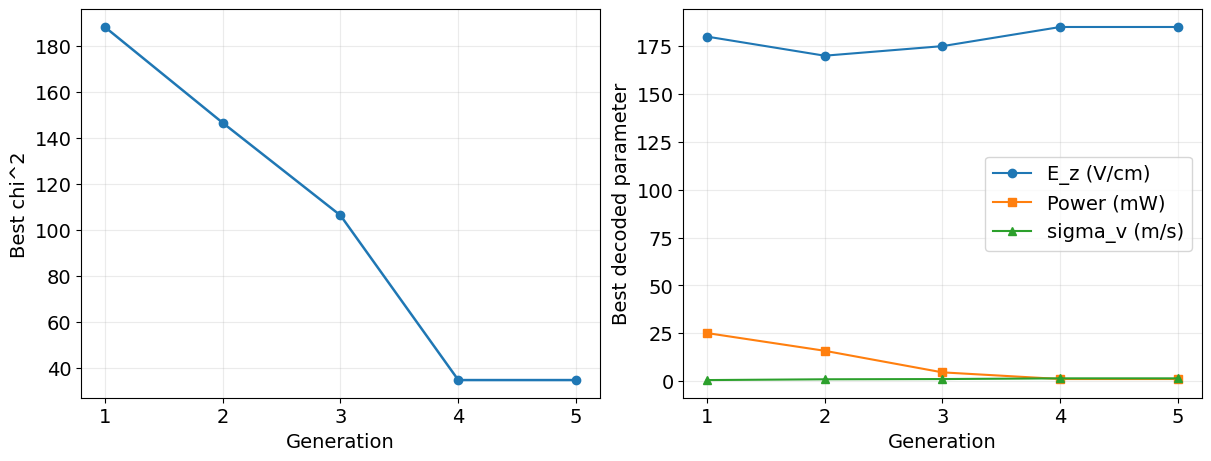

In [12]:
def _make_de_solver() -> DifferentialEvolutionSolver:
    solver_kwargs = {
        "func": objective,
        "bounds": BOUNDS,
        "init": de_init,
        "integrality": DE_INTEGRALITY,
        "maxiter": DE_MAXITER,
        "tol": DE_TOL,
        "polish": DE_POLISH,
        "updating": "immediate",
        "workers": DE_WORKERS,
        "disp": False,
    }
    solver_signature = inspect.signature(DifferentialEvolutionSolver)
    if "rng" in solver_signature.parameters:
        solver_kwargs["rng"] = np.random.default_rng(DE_SEED)
    else:
        solver_kwargs["seed"] = DE_SEED
    return DifferentialEvolutionSolver(**solver_kwargs)


def _de_best_x_and_chi2() -> tuple[np.ndarray, float]:
    energies = np.asarray(de_solver.population_energies, dtype=float)
    idx = int(np.nanargmin(energies))
    best_chi2 = float(energies[idx])
    return np.array(de_solver.x, dtype=float), best_chi2


def _de_status_row(generation: int, best_fit: dict[str, object]) -> dict[str, float | int | str]:
    field_cache = build_fit_model.cache_info()
    raw_cache = solve_raw_trace.cache_info()
    return {
        "generation": int(generation),
        "n_evaluations": int(len(evaluation_log)),
        "solver_nfev": int(getattr(de_solver, "_nfev", len(evaluation_log))),
        "best_chi2": float(best_fit["chi2"]),
        "reduced_chi2": float(best_fit["reduced_chi2"]),
        "Ez_V_cm": float(best_fit["Ez_V_cm"]),
        "power_mW": float(best_fit["power_mW"]),
        "power_index": int(best_fit["power_index"]),
        "field_index": int(best_fit["field_index"]),
        "sigma_v_m_per_s": float(best_fit["sigma_v_m_per_s"]),
        "ir_zero_MHz": float(best_fit["ir_zero_MHz"]),
        "scale": float(best_fit["scale"]),
        "field_cache_hits": int(field_cache.hits),
        "field_cache_misses": int(field_cache.misses),
        "raw_trace_cache_hits": int(raw_cache.hits),
        "raw_trace_cache_misses": int(raw_cache.misses),
        "elapsed_seconds": float(time.perf_counter() - de_fit_start),
    }


def _de_has_converged_by_patience() -> bool:
    if de_completed_generations < DE_MIN_GENERATIONS:
        return False
    return de_completed_generations - de_last_improvement_generation >= DE_PATIENCE_GENERATIONS


def _render_de_progress() -> None:
    status = {
        "completed_generations": de_completed_generations,
        "n_evaluations": len(evaluation_log),
        "stop_reason": de_stop_reason,
        "field_cache_info": build_fit_model.cache_info(),
        "raw_trace_cache_info": solve_raw_trace.cache_info(),
    }
    if "best_fit" in globals():
        status["best"] = {
            k: v
            for k, v in best_fit.items()
            if isinstance(v, (int, float, np.integer, np.floating))
        }

    display(status)

    if len(de_generation_log) == 0:
        return

    history = pd.DataFrame(de_generation_log)
    display(history.tail(10))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    axes[0].plot(history["generation"], history["best_chi2"], marker="o", lw=1.8)
    axes[0].set_xlabel("Generation")
    axes[0].set_ylabel("Best chi^2")
    axes[0].grid(alpha=0.25)

    axes[1].plot(history["generation"], history["Ez_V_cm"], marker="o", label="E_z (V/cm)")
    axes[1].plot(history["generation"], history["power_mW"], marker="s", label="Power (mW)")
    axes[1].plot(
        history["generation"],
        history["sigma_v_m_per_s"],
        marker="^",
        label="sigma_v (m/s)",
    )
    axes[1].set_xlabel("Generation")
    axes[1].set_ylabel("Best decoded parameter")
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc="best")
    display(fig)
    plt.close(fig)


if "de_solver" not in globals() or de_solver is None:
    de_solver = _make_de_solver()
    de_generation_log: list[dict[str, float | int | str]] = []
    de_completed_generations = 0
    de_fit_start = time.perf_counter()
    de_best_chi2 = np.inf
    de_last_improvement_generation = 0
    de_stop_reason = "running"
    de_stopped_early = False

if de_stop_reason not in {"running", None}:
    clear_output(wait=True)
    _render_de_progress()
else:
    for _ in range(DE_GENERATIONS_PER_CELL):
        if de_completed_generations >= DE_MAXITER:
            de_stop_reason = "maxiter reached"
            break

        try:
            next(de_solver)
        except StopIteration:
            de_stop_reason = "solver stopped"
            break

        de_completed_generations += 1
        x_best, solver_best_chi2 = _de_best_x_and_chi2()
        best_fit = evaluate_candidate(x_best, return_scan=True)

        if float(best_fit["chi2"]) < de_best_chi2 - DE_MIN_DELTA_CHI2:
            de_best_chi2 = float(best_fit["chi2"])
            de_last_improvement_generation = de_completed_generations

        de_generation_log.append(_de_status_row(de_completed_generations, best_fit))

        if _de_has_converged_by_patience():
            de_stop_reason = "early stop: no improvement"
            de_stopped_early = True

        clear_output(wait=True)
        _render_de_progress()

        if de_stop_reason != "running":
            break

de_result = opt.OptimizeResult(
    x=np.array(de_solver.x, dtype=float),
    fun=float(best_fit["chi2"]) if "best_fit" in globals() else np.inf,
    nit=int(de_completed_generations),
    nfev=int(getattr(de_solver, "_nfev", len(evaluation_log))),
    success=de_stop_reason in {"early stop: no improvement", "maxiter reached", "solver stopped"},
    message=de_stop_reason,
)

if len(de_generation_log) == 0:
    clear_output(wait=True)
    _render_de_progress()

In [13]:
evaluation_df = pd.DataFrame(evaluation_log)
evaluation_df.sort_values("chi2").head(20)

,power_index_coord,power_index,log10_power_mW,power_mW,field_index_coord,field_index,Ez_V_cm,sigma_v_m_per_s,chi2,reduced_chi2,scale,baseline,ir_zero_MHz,ndof,n_data_used,doppler_sigma_MHz,rabi_MHz,eval_seconds
104,104.0,104,0.04,1.096478,5.0,5,185.0,1.444698,34.878282,1.162609,0.385426,0.0,1837.325164,30,31,5.300894,0.042097,29.648287
111,2.0,2,-0.98,0.104713,4.0,4,180.0,1.572489,42.786707,1.426224,2.835060,0.0,1837.225164,30,31,5.769786,0.013085,29.031525
126,62.0,62,-0.38,0.416869,5.0,5,185.0,1.597322,43.659418,1.455314,0.868505,0.0,1837.275164,30,31,5.860901,0.025957,29.051277
132,96.0,96,-0.04,0.912011,3.0,3,175.0,1.464578,44.302854,1.476762,0.420293,0.0,1837.225164,30,31,5.373838,0.038842,28.699828
141,50.0,50,-0.50,0.316228,5.0,5,185.0,1.676604,59.190506,1.973017,1.123426,0.0,1837.275164,30,31,6.151803,0.022608,29.442409
105,129.0,129,0.29,1.949845,3.0,3,175.0,1.304490,68.221278,2.274043,0.241479,0.0,1837.225164,30,31,4.786440,0.056794,29.416573
110,104.0,104,0.04,1.096478,3.0,3,175.0,1.566297,68.752467,2.291749,0.372633,0.0,1837.225164,30,31,5.747066,0.042589,28.631564
135,94.0,94,-0.06,0.870964,4.0,4,180.0,1.572489,73.473966,2.449132,0.437317,0.0,1837.275164,30,31,5.769786,0.037736,29.375882
142,94.0,94,-0.06,0.870964,4.0,4,180.0,1.603981,79.322945,2.644098,0.439546,0.0,1837.275164,30,31,5.885336,0.037736,0.003092
131,52.0,52,-0.48,0.331131,5.0,5,185.0,1.771324,82.490672,2.749689,1.093083,0.0,1837.275164,30,31,6.499350,0.023134,29.627316


In [14]:
field_build_df = pd.DataFrame(FIELD_BUILD_LOG).drop_duplicates("field_index")
field_build_df.sort_values("Ez_V_cm")

,field_index,Ez_V_cm,levels,excited_levels,build_seconds
2,0,160.0,38,14,7.791343
1,1,165.0,38,14,8.222489
0,2,170.0,38,14,8.734857
3,3,175.0,38,14,7.674684
4,4,180.0,38,14,7.856586
5,5,185.0,38,14,7.503242
6,6,190.0,38,14,7.525730


## Optional local polish at fixed best field

This keeps the best discrete electric field fixed and optimizes only integer
power index and transverse velocity. `ir_zero_MHz` and the amplitude scale are
still profiled inside the objective.

In [15]:
RUN_FIXED_FIELD_POLISH = False

if RUN_FIXED_FIELD_POLISH:
    best_field_index = int(best_fit["field_index"])

    def objective_fixed_field(z: np.ndarray) -> float:
        power_index = power_index_from_coord(z[0])
        sigma_v_m_per_s = float(np.clip(z[1], BOUNDS[2][0], BOUNDS[2][1]))
        x = np.array([power_index, best_field_index, sigma_v_m_per_s])
        return objective(x)

    z0 = np.array(
        [
            float(best_fit["power_index"]),
            float(best_fit["sigma_v_m_per_s"]),
        ]
    )

    polish_result = opt.minimize(
        objective_fixed_field,
        z0,
        method="Nelder-Mead",
        options={"maxiter": 80, "xatol": 1e-3, "fatol": 0.1, "disp": True},
    )

    polished_x = np.array(
        [
            power_index_from_coord(polish_result.x[0]),
            best_field_index,
            polish_result.x[1],
        ]
    )
    best_fit = evaluate_candidate(polished_x, return_scan=True)
    display(
        {
            "polish_success": bool(polish_result.success),
            "polish_message": polish_result.message,
            "best": {
                k: v
                for k, v in best_fit.items()
                if isinstance(v, (int, float, np.integer, np.floating))
            },
            "field_cache_info": build_fit_model.cache_info(),
            "raw_trace_cache_info": solve_raw_trace.cache_info(),
        }
    )

## Final higher-resolution evaluation and plot

In [16]:
# Re-evaluate the current best point with a finer detuning grid.
best_x = np.array(
    [
        float(best_fit["power_index"]),
        float(best_fit["field_index"]),
        float(best_fit["sigma_v_m_per_s"]),
    ]
)

final_fit = evaluate_candidate(
    best_x,
    detuning_step_MHz=FINAL_DETUNING_STEP_MHZ,
    reltol=FINAL_REL_TOL,
    abstol=FINAL_ABS_TOL,
    return_scan=True,
)

final_table = pd.DataFrame(
    [
        {
            key: value
            for key, value in final_fit.items()
            if isinstance(value, (int, float, np.integer, np.floating))
        }
    ]
)
final_table

,power_index_coord,power_index,log10_power_mW,power_mW,field_index_coord,field_index,Ez_V_cm,sigma_v_m_per_s,chi2,reduced_chi2,scale,baseline,ir_zero_MHz,ndof,n_data_used,doppler_sigma_MHz,rabi_MHz
0,104.0,104,0.04,1.096478,5.0,5,185.0,1.444698,71.530076,2.384336,0.384509,0.0,1837.325164,30,31,5.300894,0.042097


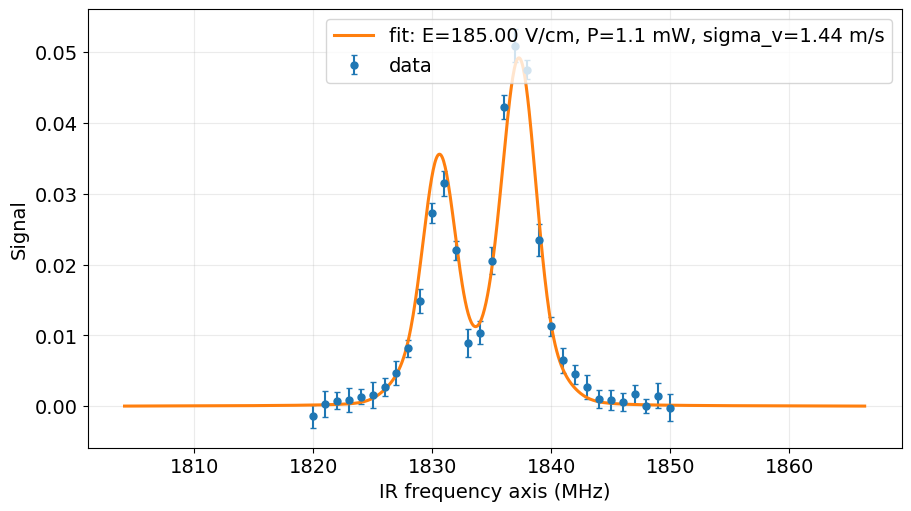

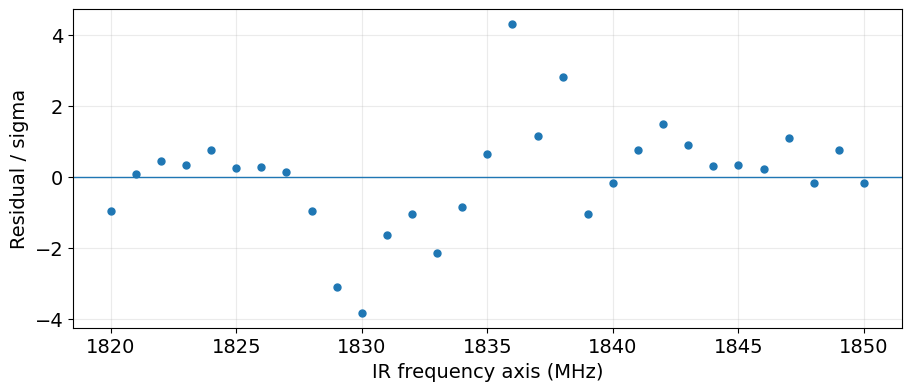

In [17]:
scan = final_fit["scan"]
scale = float(final_fit["scale"])
baseline = float(final_fit["baseline"])
ir_zero_MHz = float(final_fit["ir_zero_MHz"])

x_model_ir_MHz = ir_zero_MHz - scan["detuning_MHz"] / 4.0
y_model = scale * scan["doppler_photons"] + baseline
order = np.argsort(x_model_ir_MHz)

model_at_data_scaled = scale * final_fit["model_at_data"] + baseline
residual = y_data - model_at_data_scaled
mask = final_fit["mask"]

fig, ax = plt.subplots(figsize=(9.0, 5.0), constrained_layout=True)
ax.errorbar(x_ir_MHz, y_data, yerr=sy_data, fmt="o", ms=5, capsize=2, label="data")
ax.plot(
    x_model_ir_MHz[order],
    y_model[order],
    lw=2.2,
    label=(
        f"fit: E={final_fit['Ez_V_cm']:.2f} V/cm, "
        f"P={final_fit['power_mW']:.1f} mW, "
        f"sigma_v={final_fit['sigma_v_m_per_s']:.2f} m/s"
    ),
)
ax.set_xlabel("IR frequency axis (MHz)")
ax.set_ylabel("Signal")
ax.grid(alpha=0.25)
ax.legend()

fig, ax = plt.subplots(figsize=(9.0, 3.8), constrained_layout=True)
ax.axhline(0, lw=1)
ax.errorbar(x_ir_MHz[mask], residual[mask] / sy_data[mask], fmt="o", ms=5, capsize=2)
ax.set_xlabel("IR frequency axis (MHz)")
ax.set_ylabel("Residual / sigma")
ax.grid(alpha=0.25)

## Field-cache/profile diagnostics

These plots are helpful for checking whether the discrete-field strategy behaved
sensibly. The objective can evaluate many candidates at the same field without
rebuilding the OBE system.

{'field_cache_info': CacheInfo(hits=270, misses=7, maxsize=None, currsize=7),
 'raw_trace_cache_info': CacheInfo(hits=24, misses=126, maxsize=None, currsize=126),
 'fields_built': [160.0, 165.0, 170.0, 175.0, 180.0, 185.0, 190.0]}

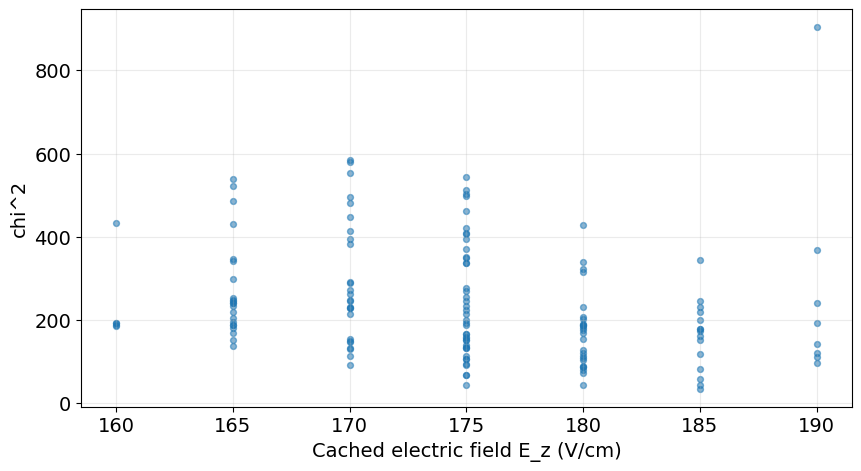

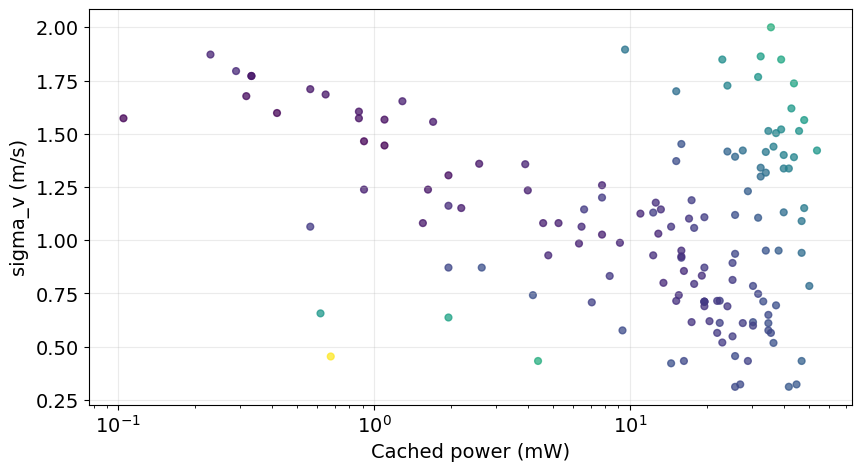

In [18]:
if len(evaluation_log) > 0:
    evaluation_df = pd.DataFrame(evaluation_log)

    fig, ax = plt.subplots(figsize=(8.5, 4.6), constrained_layout=True)
    finite = np.isfinite(evaluation_df["chi2"])
    ax.scatter(
        evaluation_df.loc[finite, "Ez_V_cm"],
        evaluation_df.loc[finite, "chi2"],
        s=18,
        alpha=0.55,
    )
    ax.set_xlabel("Cached electric field E_z (V/cm)")
    ax.set_ylabel("chi^2")
    ax.grid(alpha=0.25)

    fig, ax = plt.subplots(figsize=(8.5, 4.6), constrained_layout=True)
    ax.scatter(
        evaluation_df.loc[finite, "power_mW"],
        evaluation_df.loc[finite, "sigma_v_m_per_s"],
        c=evaluation_df.loc[finite, "chi2"],
        s=24,
        alpha=0.75,
    )
    ax.set_xscale("log")
    ax.set_xlabel("Cached power (mW)")
    ax.set_ylabel("sigma_v (m/s)")
    ax.grid(alpha=0.25)

display(
    {
        "field_cache_info": build_fit_model.cache_info(),
        "raw_trace_cache_info": solve_raw_trace.cache_info(),
        "fields_built": sorted({entry["Ez_V_cm"] for entry in FIELD_BUILD_LOG}),
    }
)

## Optional refined field grid around the best field

After a coarse fit, you can refine `E_STEP_V_CM` by creating a narrower grid around
the best field and rerunning the notebook from the cached-builder cell onward.

Example manual edit:

```python
E_GRID_V_CM = np.arange(final_fit["Ez_V_cm"] - 2.0, final_fit["Ez_V_cm"] + 2.0001, 0.1)
START_FIELD_INDEX = int(np.argmin(np.abs(E_GRID_V_CM - final_fit["Ez_V_cm"])))
build_fit_model.cache_clear()
FIELD_BUILD_LOG.clear()
```

Then rerun the differential-evolution section.